### PCA in Machine Learning Workflows
#### Machine Learning I - Maestría en Analítica Aplicada
#### Universidad de la Sabana
#### Prof: Hugo Franco
#### Example: Principal Component Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import time


The IRIS dataset is used to illustrate the usage of PCA in a Supervised Learning pipeline

In [3]:
# Load and prepare the iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# 1. Train baseline k-NN model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline model without PCA
start_time = time.time()
baseline_model = KNeighborsClassifier(n_neighbors=3)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_time = time.time() - start_time

print("Baseline Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, baseline_pred):.4f}")
print(f"Training time: {baseline_time:.4f} seconds\n")



Baseline Model Performance:
Accuracy: 1.0000
Training time: 0.0060 seconds



In [4]:
# 2. Create and train Pipeline with PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('knn', KNeighborsClassifier(n_neighbors=3))
])

start_time = time.time()
pca_pipeline.fit(X_train, y_train)
pipeline_pred = pca_pipeline.predict(X_test)
pipeline_time = time.time() - start_time

print("PCA Pipeline Performance:")
print(f"Accuracy: {accuracy_score(y_test, pipeline_pred):.4f}")
print(f"Training time: {pipeline_time:.4f} seconds\n")

PCA Pipeline Performance:
Accuracy: 0.9333
Training time: 0.2473 seconds



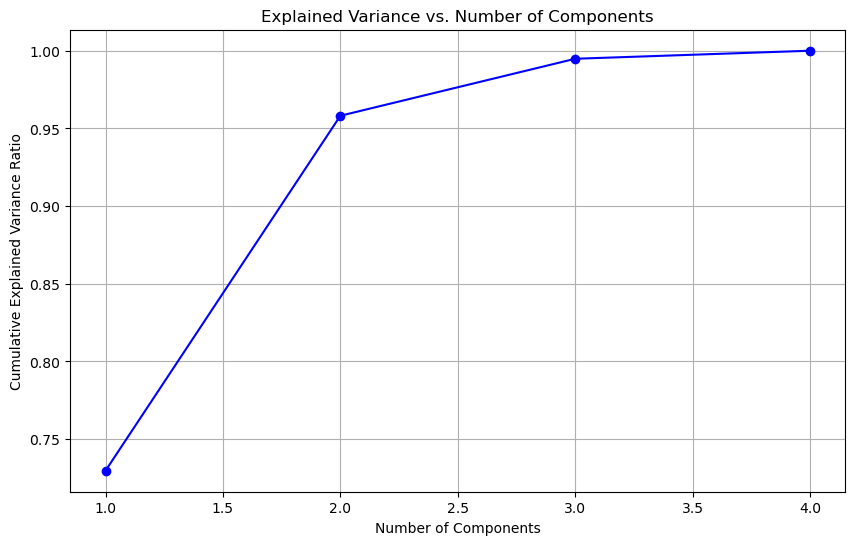

In [5]:
# 3. Analyze explained variance ratio
pca = PCA()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca.fit(X_scaled)

# Plot cumulative explained variance
plt.figure(figsize=(10, 6))
cumsum = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumsum) + 1), cumsum, 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

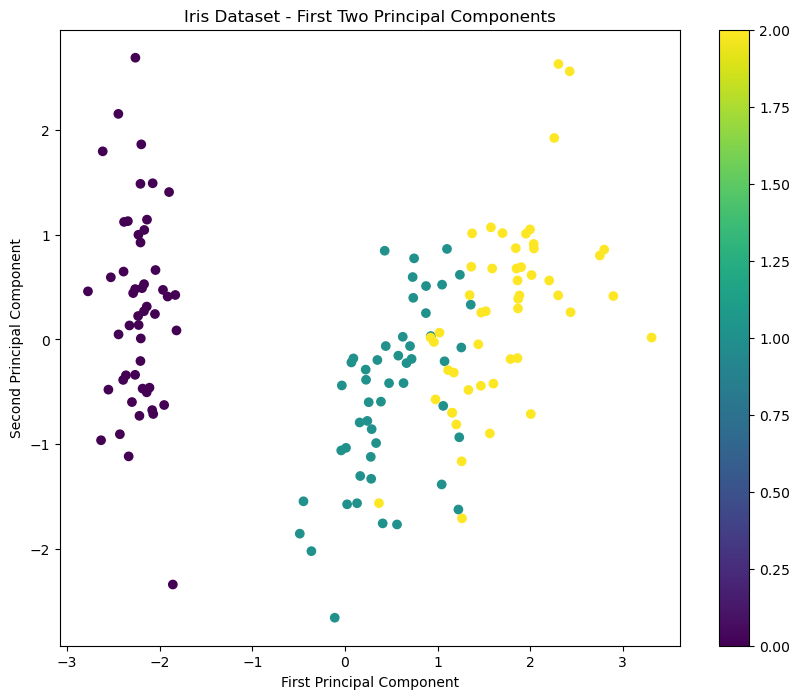

Explained variance ratio for first two components:
PC1: 0.7296
PC2: 0.2285
Total: 0.9581


In [6]:
# 4. Visualize 2D projection
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='viridis')
plt.xlabel(f'First Principal Component')
plt.ylabel(f'Second Principal Component')
plt.title('Iris Dataset - First Two Principal Components')
plt.colorbar(scatter)
plt.show()

# Print the explained variance ratio for the first two components
print("Explained variance ratio for first two components:")
print(f"PC1: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"Total: {sum(pca_2d.explained_variance_ratio_):.4f}")

#### Class activity - Workshop 3 Challenge: 
1. Add and organize this example according to the Data Science Workflow
2. Apply the workflow to the wine dataset
3. Complete the steps in the Supervised Learning Workflow for Data Science according to data preparation and per-model requirements and recommendations in this course, up-to-date
4. **Compare the classification performance using the complete set of original   and using only two PCA-transformed features.**
5. Modify the example to perform only a binary classification (good > 6) and compare your results with the multiclass performance

##### Wine Dataset Description
The Wine Quality dataset contains features like acidity, pH, alcohol content, and quality ratings. We'll convert the quality ratings into a binary classification problem.

* Number of instances: 1599
* Features: 11 physicochemical properties
* Target: Binary (Good/Poor quality) and multiclass (Poor, Fair, and Good quality)
* Features include:
* Fixed acidity
* Volatile acidity
* Citric acid
* Residual sugar
* Chlorides
* Free sulfur dioxide
* Total sulfur dioxide
* Density
* pH
* Sulphates
* Alcohol

Three-Class Distribution:
 quality_class
poor    744
fair    638
good    217
Name: count, dtype: int64


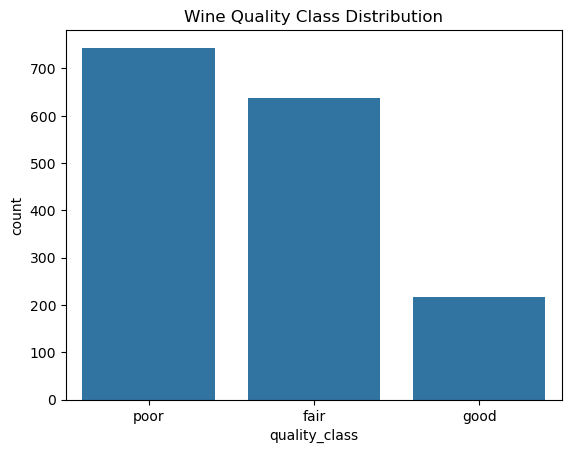

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from xgboost import plot_importance
import matplotlib.pyplot as plt
import seaborn as sns

# Load wine quality dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

# Convert quality scores to three classes
def quality_to_class(quality):
    if quality <= 5:
        return 'poor'
    elif quality <= 6:
        return 'fair'
    else:
        return 'good'

# Add new column with three classes
df['quality_class'] = df['quality'].apply(quality_to_class)

# Show distribution of new classes
print("Three-Class Distribution:\n", df['quality_class'].value_counts())

# Visualize class distribution
plt.figure()
sns.countplot(data=df, x='quality_class', order=['poor', 'fair', 'good'])
plt.title('Wine Quality Class Distribution')
plt.show()


### 1. Preparación, Modelado y Comparación

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

### 2. Preparación de Datos para Análisis Multiclase

In [23]:
print("### 2. Preparando datos para el análisis multiclase... ###")
X = df.drop(['quality', 'quality_class'], axis=1)
y_labels = df['quality_class']
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Datos multiclase listos.\n")

### 2. Preparando datos para el análisis multiclase... ###
Datos multiclase listos.



### 3. Comparación de Modelos (Multiclase)

In [24]:
print("### 3. Realizando análisis multiclase... ###")
# Modelo 1: Todas las características
xgb_full_mc = XGBClassifier(objective='multi:softmax', num_class=3, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_full_mc.fit(X_train_mc, y_train_mc)
y_pred_full_mc = xgb_full_mc.predict(X_test_mc)
acc_full_mc = accuracy_score(y_test_mc, y_pred_full_mc)
print(f"Precisión (Multiclase, Todas las Características): {acc_full_mc:.4f}")

### 3. Realizando análisis multiclase... ###
Precisión (Multiclase, Todas las Características): 0.8313


c:\Users\jhonr\miniconda3\envs\taller2BigData\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:47:05] WARNING: D:\bld\xgboost-split_1758007517675\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Modelo 2: 2 Componentes PCA

In [25]:
pipeline_pca_mc = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('xgb', XGBClassifier(objective='multi:softmax', num_class=3, use_label_encoder=False, eval_metric='mlogloss', random_state=42))
])
pipeline_pca_mc.fit(X_train_mc, y_train_mc)
y_pred_pca_mc = pipeline_pca_mc.predict(X_test_mc)
acc_pca_mc = accuracy_score(y_test_mc, y_pred_pca_mc)
print(f"Precisión (Multiclase, 2 Componentes PCA): {acc_pca_mc:.4f}\n")

Precisión (Multiclase, 2 Componentes PCA): 0.7000



c:\Users\jhonr\miniconda3\envs\taller2BigData\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:47:47] WARNING: D:\bld\xgboost-split_1758007517675\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Preparación de Datos para Análisis Binario

In [26]:
print("### 4. Preparando datos para el análisis binario... ###")
df['quality_binary'] = (df['quality'] > 6).astype(int)
y_binary = df['quality_binary']
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)
print("Datos binarios listos.\n")

### 4. Preparando datos para el análisis binario... ###
Datos binarios listos.



### 5. Comparación de Modelos (Binario)

In [27]:
print("### 5. Realizando análisis binario... ###")
# Modelo 3: Todas las características
xgb_full_bin = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_full_bin.fit(X_train_bin, y_train_bin)
y_pred_full_bin = xgb_full_bin.predict(X_test_bin)
acc_full_bin = accuracy_score(y_test_bin, y_pred_full_bin)
print(f"Precisión (Binaria, Todas las Características): {acc_full_bin:.4f}")

### 5. Realizando análisis binario... ###
Precisión (Binaria, Todas las Características): 1.0000


c:\Users\jhonr\miniconda3\envs\taller2BigData\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:48:58] WARNING: D:\bld\xgboost-split_1758007517675\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Modelo 4: 2 Componentes PCA

In [28]:
pipeline_pca_bin = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])
pipeline_pca_bin.fit(X_train_bin, y_train_bin)
y_pred_pca_bin = pipeline_pca_bin.predict(X_test_bin)
acc_pca_bin = accuracy_score(y_test_bin, y_pred_pca_bin)
print(f"Precisión (Binaria, 2 Componentes PCA): {acc_pca_bin:.4f}\n")

Precisión (Binaria, 2 Componentes PCA): 0.9563



c:\Users\jhonr\miniconda3\envs\taller2BigData\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:49:26] WARNING: D:\bld\xgboost-split_1758007517675\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [29]:
# --- Conclusión Final del Desafío ---
print("==========================================================")
print("###                Conclusiones Finales                ###")
print("==========================================================")
print("\nTabla Resumen de Precisión:")
print("----------------------------------------------------------")
print(f"| {'Escenario':<12} | {'Características':<18} | {'Precisión':<10} |")
print("----------------------------------------------------------")
print(f"| {'Multiclase':<12} | {'Todas (11)':<18} | {acc_full_mc:<10.4f} |")
print(f"| {'Multiclase':<12} | {'2 Componentes PCA':<18} | {acc_pca_mc:<10.4f} |")
print(f"| {'Binario':<12} | {'Todas (11)':<18} | {acc_full_bin:<10.4f} |")
print(f"| {'Binario':<12} | {'2 Componentes PCA':<18} | {acc_pca_bin:<10.4f} |")
print("----------------------------------------------------------\n")

print("Análisis de Resultados:")
print("1. Características Completas vs. PCA: El modelo con todas las características originales")
print("   es más preciso en ambos escenarios. La reducción a 2 componentes pierde información,")
print("   lo que afecta el rendimiento.\n")

print("2. Multiclase vs. Binario: El rendimiento es mucho mayor en la clasificación binaria.")
print("   Simplificar el problema a dos clases ('bueno' vs. 'malo') permite al modelo")
print("   encontrar patrones más claros y clasificar con mayor eficacia.")

###                Conclusiones Finales                ###

Tabla Resumen de Precisión:
----------------------------------------------------------
| Escenario    | Características    | Precisión  |
----------------------------------------------------------
| Multiclase   | Todas (11)         | 0.8313     |
| Multiclase   | 2 Componentes PCA  | 0.7000     |
| Binario      | Todas (11)         | 1.0000     |
| Binario      | 2 Componentes PCA  | 0.9563     |
----------------------------------------------------------

Análisis de Resultados:
1. Características Completas vs. PCA: El modelo con todas las características originales
   es más preciso en ambos escenarios. La reducción a 2 componentes pierde información,
   lo que afecta el rendimiento.

2. Multiclase vs. Binario: El rendimiento es mucho mayor en la clasificación binaria.
   Simplificar el problema a dos clases ('bueno' vs. 'malo') permite al modelo
   encontrar patrones más claros y clasificar con mayor eficacia.


### Gráfico Comparativo de Resultados

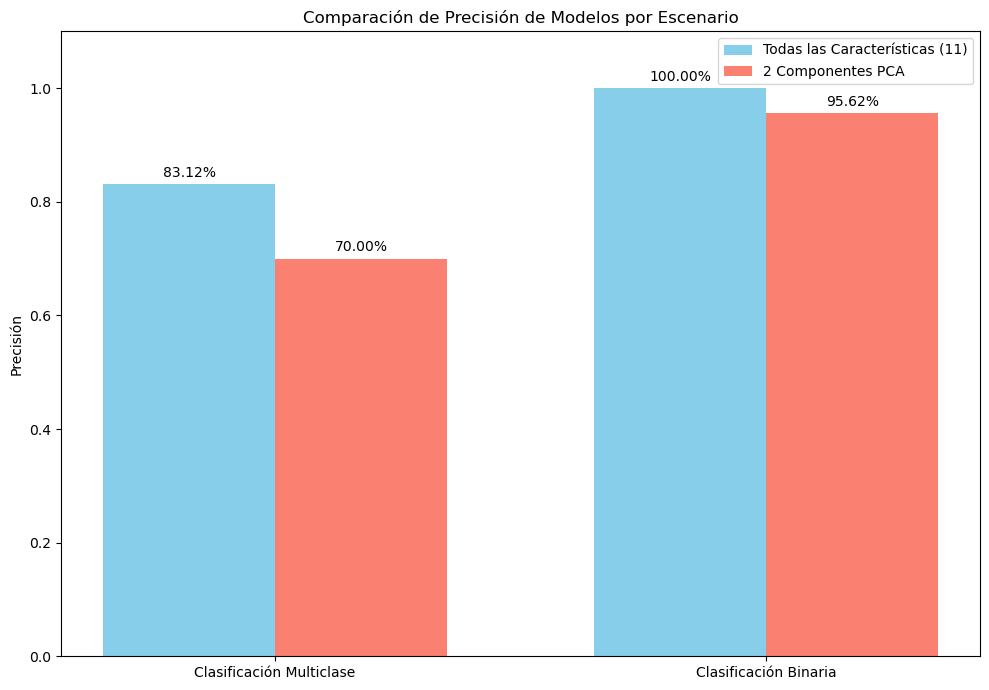

In [31]:

labels = ['Clasificación Multiclase', 'Clasificación Binaria']
full_features_acc = [acc_full_mc, acc_full_bin]
pca_features_acc = [acc_pca_mc, acc_pca_bin]
x = np.arange(len(labels))
width = 0.35  # Ancho de las barras
fig, ax = plt.subplots(figsize=(10, 7))

rects1 = ax.bar(x - width/2, full_features_acc, width, label='Todas las Características (11)', color='skyblue')
rects2 = ax.bar(x + width/2, pca_features_acc, width, label='2 Componentes PCA', color='salmon')

ax.set_ylabel('Precisión')
ax.set_title('Comparación de Precisión de Modelos por Escenario')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1.1)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2%}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()